PROJETO 13

Importação de Bibliotecas

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Atribuição do DataFrame

In [20]:
df_gym = pd.read_csv('gym_churn_us.csv', dtype={'Month_to_end_contract': int})
df_gym.columns = df_gym.columns.str.lower()

Pré-Análise do DataFrame

In [21]:
df_gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   int64  
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

In [22]:
df_gym.head(10)

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1,3,1.113884,1.120078,0
5,1,1,0,0,1,1,1,34,450.743960,1,3,2.623477,2.637007,0
6,1,1,1,1,0,6,1,32,94.266389,6,2,1.138941,1.277242,0
7,0,1,0,0,1,1,0,30,217.786641,1,0,1.213502,1.049387,1
8,1,1,1,1,1,1,1,23,45.409909,1,1,1.106239,1.059333,0
9,0,1,0,0,1,1,0,31,65.310836,1,11,1.810852,1.951368,0


In [23]:
df_gym.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Pré-Processamento do DataFrame

In [24]:
df_gym['month_to_end_contract'].unique()

array([ 5, 12,  1,  6,  3, 10, 11,  9,  4,  7,  8,  2])

ANÁLISE EXPLORATÓRIA DE DADOS

Olhe para o conjunto de dados: ele contém alguma característica ausente? Estude a média de valores e desvio padrão (use o método describe()).

Nenhuma característica ausente, o info detectou 4000 valores dos quais estão todos presentes em todas colunas.

A maioria das colunas tem valores binários, então em colunas que a média for mais abaixo de 0,5 significa que tem uma incidencia maior de valores com o número 0, médias acima de 0,5 significa incidencia maior do valor 1.

Já o desvio padrão analisando somente pelo método describe não mostra nenhuma anomalia referente aos dados, porém um ponto a se destacar é o desvio padrão de lifetime que é ~3,7 sendo que o valor máximo é 31, o que significa que a maioria dos alunos são pessoas que entraram recentemente na academia, tendo poucos que estão há bastante tempo.

Já o avg_additional_charges_total tem um desvio padrão de ~96 com média de ~147, o que significa que a disparidade entre os gastos dos clientes é grande.

Observe a média dos valores médios das características em dois grupos: para aqueles que ficaram (use o método groupby()).

In [25]:
df_gym.groupby('churn').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Clientes que não cancelaram tendem a ir mais vezes na semana, foram mais vezes no mês atual, estão há mais tempo na academia (lifetime médio quase 5x maior), têm mais tempo de contrato em aberto, consomem mais produtos adicionais, têm uma porção maior de pessoas que faz aulas em grupo, pegaram um período de contrato mais longo, vieram de uma oferta de amigos, são funcionários de uma empresa parceira e moram mais perto da academia.

Não faz diferença se vai cancelar ou não: o gênero (médias praticamente idênticas: 0.510 vs 0.510), se forneceu ou não o número de telefone, e a diferença na idade média é pequena, apenas 3 anos.

Faça histogramas de barra e distribuições de características para aqueles que saíram (rotatividade) e aqueles que ficaram.

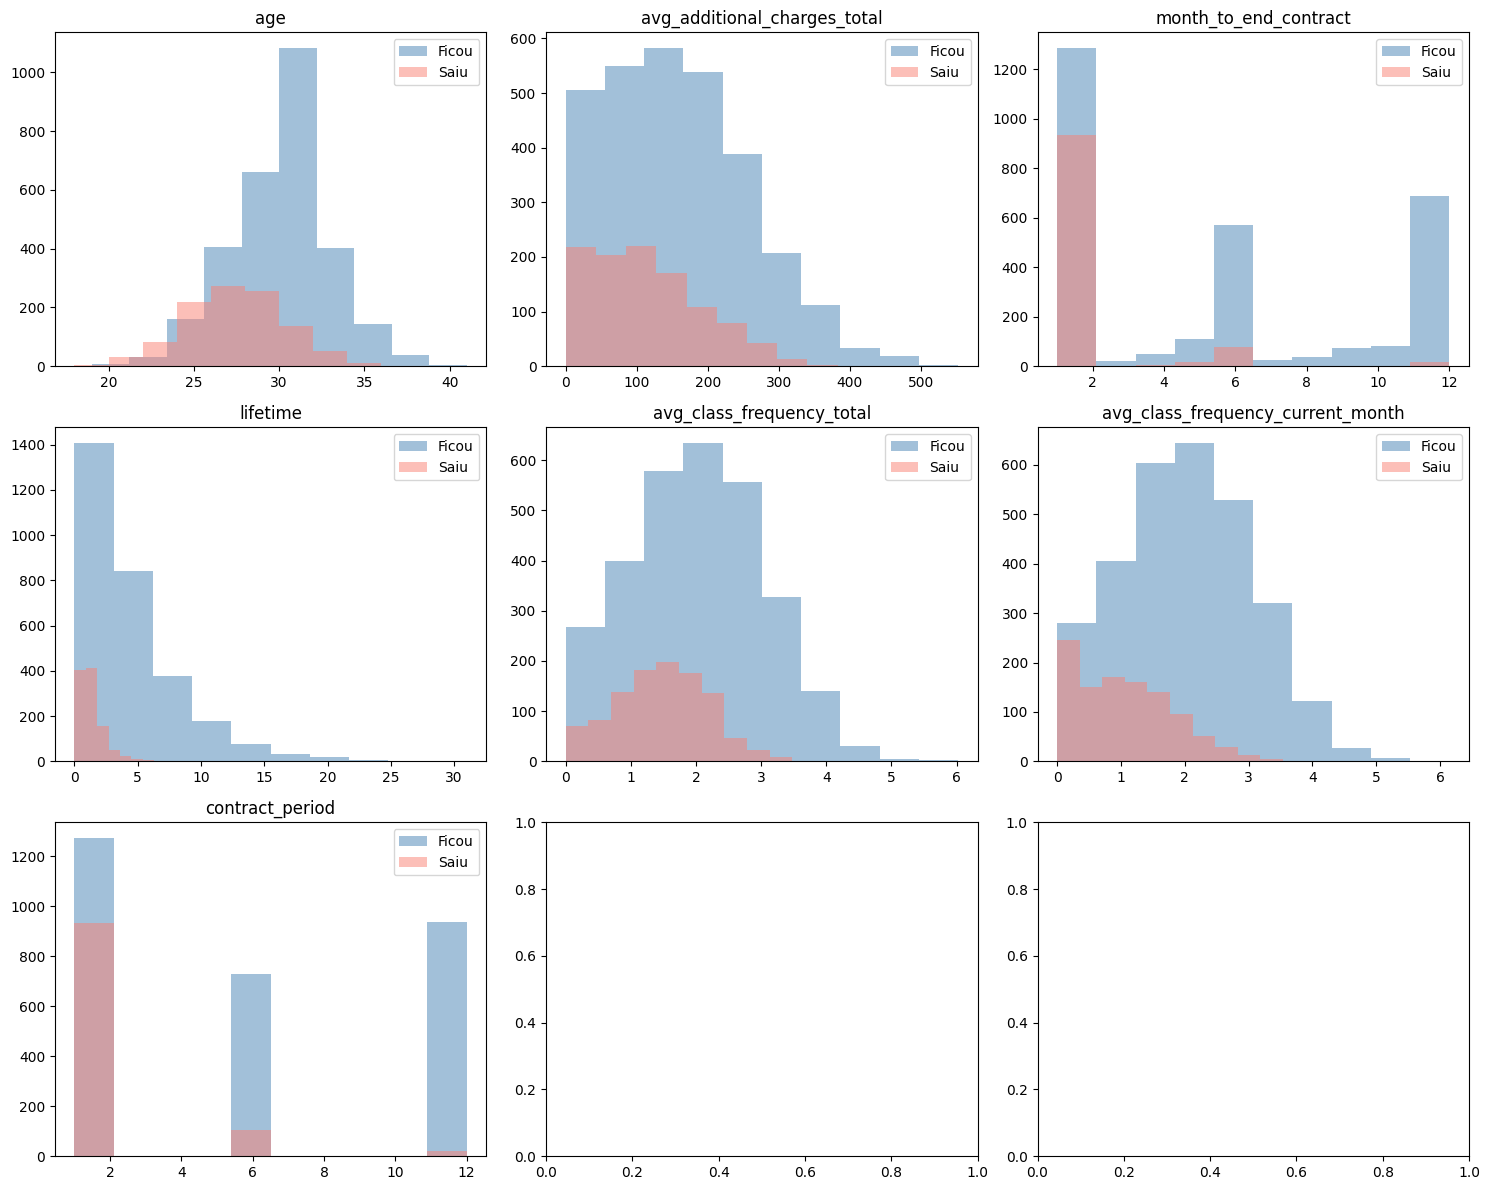

In [26]:
colunas_continuas = ['age', 'avg_additional_charges_total', 'month_to_end_contract', 
                     'lifetime', 'avg_class_frequency_total', 
                     'avg_class_frequency_current_month', 'contract_period']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(colunas_continuas):
    churn_0 = df_gym[df_gym['churn'] == 0][col]
    churn_1 = df_gym[df_gym['churn'] == 1][col]
    
    axes[i].hist(churn_0, alpha=0.5, label='Ficou', color='steelblue')
    axes[i].hist(churn_1, alpha=0.5, label='Saiu', color='salmon')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

Construa a matriz de correlação e a exiba.

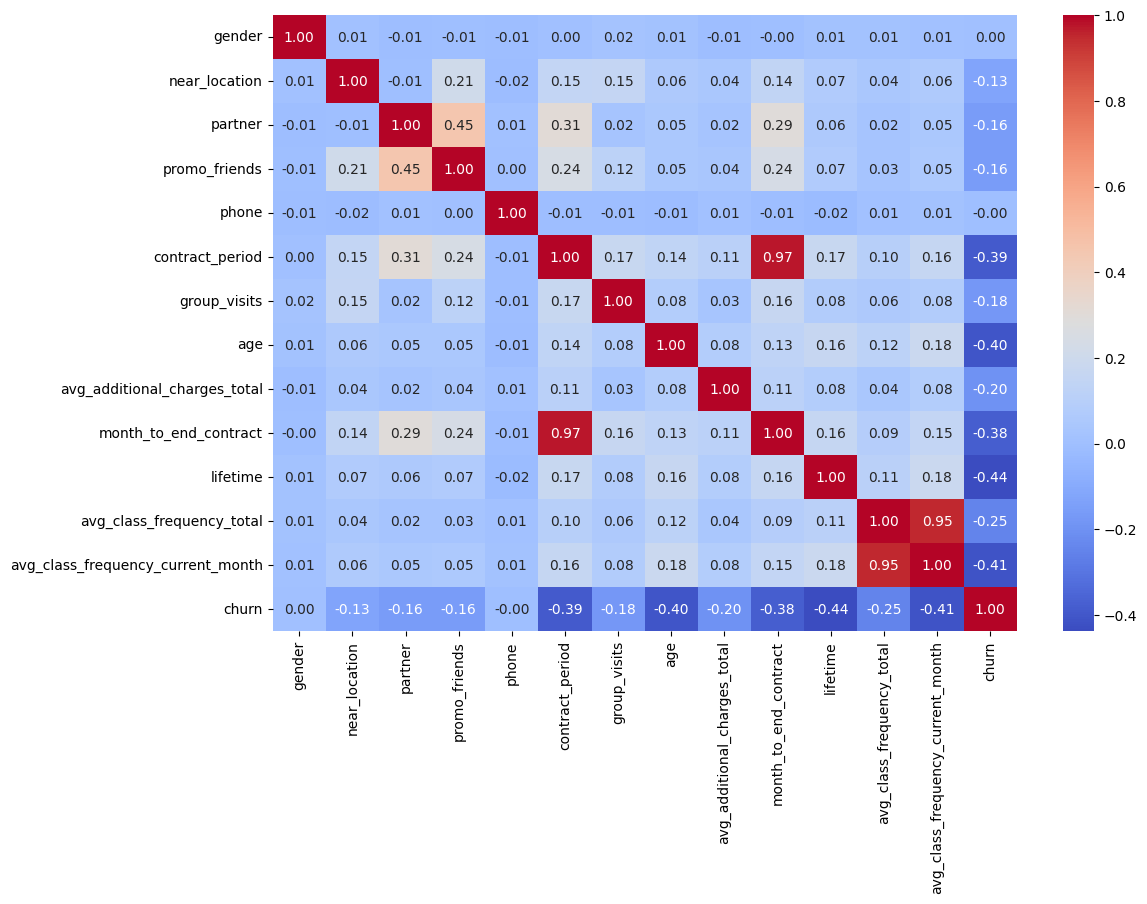

In [27]:
corr_matrix = df_gym.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()